<h1 style="font-size: 35px;">Istraživanje podataka - Reuters 50-50</h1>

**Student:** Nikola Krstajić  
**Broj indeksa:** 174/2020  
**Dataset:** Reuters 50-50 (C50)  
**Zadatak:** Klasterovanje

## Sadržaj projekta
1. **Ucitavanje neophodnih biblioteka**
2. **Učitavanje i istraživanje podataka**
3. **Preprocesiranje teksta**
4. **Redukcija dimenzionalnosti i vizualizacija**
5. **Klasterovanje (Modelovanje)**
6. **Evaluacija i interpretacija rezultata**

<span style="font-size: 20px;">**1.Ucitavanje neophodnih biblioteka**</span>

In [1]:
import pandas as pd
import numpy as np 
from matplotlib import pyplot as plt
import os

import pickle
import re

import joblib

import requests
import io
import zipfile

import scipy.cluster.hierarchy as sch

import nltk
from nltk.stem import WordNetLemmatizer
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import warnings
warnings.filterwarnings('ignore')


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import hstack

from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score,homogeneity_score, completeness_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.cluster import BisectingKMeans
from sklearn.mixture import GaussianMixture
from sklearn.cluster import Birch

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
    nltk.download('omw-1.4')


print("Sve biblioteke su uspesno ucitane")

Sve biblioteke su uspesno ucitane


[nltk_data] Downloading package wordnet to /home/nikola/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/nikola/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


<span style="font-size: 20px;">**2.Ucitavanje podataka**</span>

In [2]:
def get_data():
    base_data_path = os.path.abspath(os.path.join("..","data"))
    url = "https://archive.ics.uci.edu/static/public/217/reuter+50+50.zip"

    print("Zapocinjem proces")
    try:
        print("Pokusavam download sa UCI sajta")
        response = requests.get(url,timeout = 15)

        if response.status_code == 200:
            os.makedirs(base_data_path,exist_ok= True)

            with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
                zip_ref.extractall(base_data_path)
            print("Uspesno preuzeto i raspakovano u folder data")
        else:
            print("Server je vratio gresku, prelazim na lokalno ucitavanje")
        
    except Exception as e:
        print("Download nije uspeo, nastavljam sa pokusajem lokalnog ucitavanja fajlova")
    
        
    all_texts = []
    all_labels = []
    subsets = ['C50train', 'C50test']
    
    for subset in subsets:
        subset_path = os.path.join(base_data_path,subset)
        if os.path.exists(subset_path):
            print("Ucitavam tekstove iz " + subset)
            for author_name in sorted(os.listdir(subset_path)):
                author_folder = os.path.join(subset_path,author_name)
                if os.path.isdir(author_folder):
                    for file_name in os.listdir(author_folder):
                        if file_name.endswith(".txt"):
                            file_full_path = os.path.join(author_folder,file_name)
                            with open(file_full_path,"r",encoding= "utf-8",errors="ignore") as f:
                                all_texts.append(f.read())
                                all_labels.append(author_name)
            
    df = pd.DataFrame(
    {"text" : all_texts,
    "author" : all_labels})

    print("Zavrsen proces")
    print("Broj ucitanih tekstova je  " + str(len(df)))
    return df
df = get_data()

if df is not None:
    print(df.head())

Zapocinjem proces
Pokusavam download sa UCI sajta
Uspesno preuzeto i raspakovano u folder data
Ucitavam tekstove iz C50train
Ucitavam tekstove iz C50test
Zavrsen proces
Broj ucitanih tekstova je  5000
                                                text         author
0  An influential economic research group is prep...  AaronPressman
1  When a company in California sells a book to a...  AaronPressman
2  The Internet continued to grow in leaps and bo...  AaronPressman
3  The Commodity Futures Trading Commission, one ...  AaronPressman
4  Legislators introduced two bills Thursday to o...  AaronPressman


<span style="font-size: 17px;">**2.1.OSNOVNE STATISTIKE**</span>

In [3]:


## Izbacujemo reci koje su ceste u engleskom a ne nose znacanje, kao i reci koje se pojavljuju previse puta u tekstovima i ne doprinose analizi
custom_stop_words = ENGLISH_STOP_WORDS.union({'said', 'million', 'billion', 'year', 'new', 'percent', 'company', 'market', 'analysts'})

def get_clean_text(text):
    raw_words = text.split()
    word_count = len(raw_words)

    clean = text.lower()
    clean = re.sub(r'[^a-z\s]', ' ', clean)
    clean_words = [w for w in clean.split() if w not in custom_stop_words and len(w) > 2]

    return pd.Series([word_count, " ".join(clean_words)])
df[['word_count', 'clean_text']] = df['text'].apply(get_clean_text)


## Prikaz statistike
num_authors = len(set(df['author']))
total_texts = len(df)
avg_words = df['word_count'].mean()
min_idx = (df['word_count']).idxmin()
max_idx = (df['word_count']).idxmax()


print("="*60)
print("OSNOVNA STATISTIKA SKUPA")
print("="*60)
print("Ukupan broj autora: " + str(num_authors))
print("Ukupan broj tekstova: " + str(total_texts)) 
print("Prosecna broj reci u tekstu "  + str(avg_words))
print("="*60)
print("Autor najduzeg teksta : " + df.iloc[max_idx]['author'])
print("Broj reci : " + str(df.iloc[max_idx]['word_count']))
print("="*60)
print("Autor najkraceg teksta " + df.iloc[min_idx]['author'])
print("Broj reci : " + str(df.iloc[min_idx]['word_count']))

print("="*60)
all_clean_words = " ".join(df['clean_text']).split()
top10 = Counter(all_clean_words).most_common(10)

print("TOP 10 NAJCESCIH RECI")
for word,count in top10:
    print(f"{word.ljust(12)} : {count}")

OSNOVNA STATISTIKA SKUPA
Ukupan broj autora: 50
Ukupan broj tekstova: 5000
Prosecna broj reci u tekstu 505.6604
Autor najduzeg teksta : JimGilchrist
Broj reci : 1499
Autor najkraceg teksta AaronPressman
Broj reci : 51
TOP 10 NAJCESCIH RECI
china        : 6625
hong         : 4244
kong         : 4242
share        : 3831
business     : 3825
group        : 3802
government   : 3664
corp         : 3583
bank         : 3519
industry     : 3505


<span style="font-size: 17px;">**2.2.PRIKAZ BALANSIRANOSTI KLASA**</span>

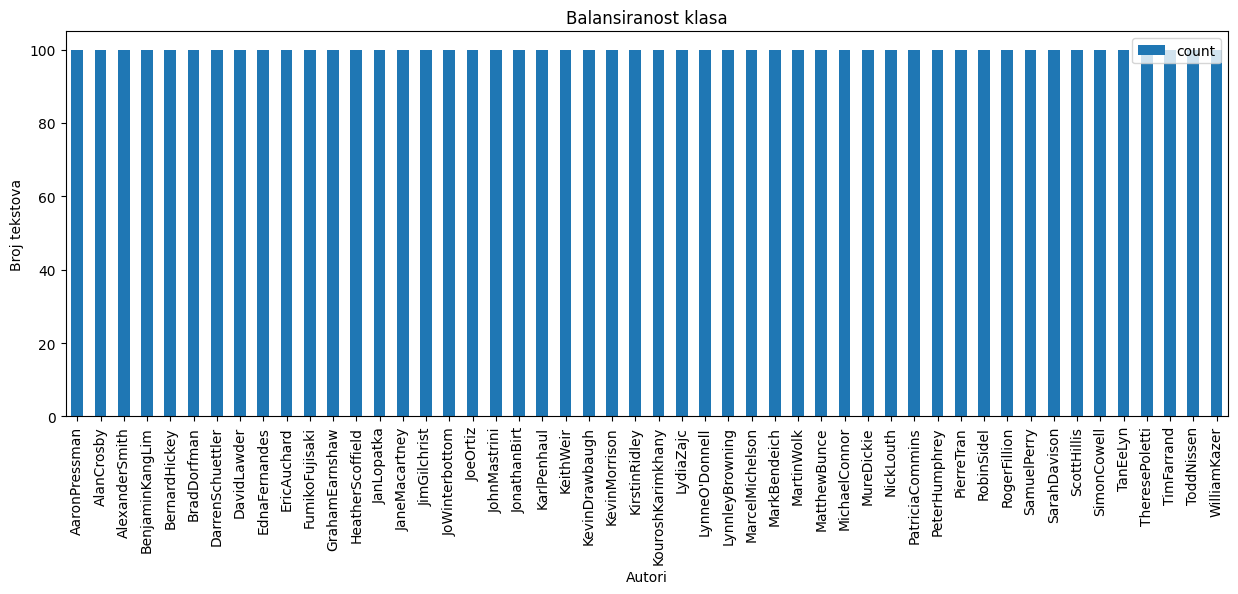

In [4]:


df['author'].value_counts().plot(kind = "bar",figsize = (15,5))

plt.xlabel("Autori")
plt.ylabel("Broj tekstova")
plt.legend()
plt.title("Balansiranost klasa")
plt.show()

<span style="font-size: 17px;">**2.3 PROSECNA DUZINA RECENICE PO AUTORU**</span>

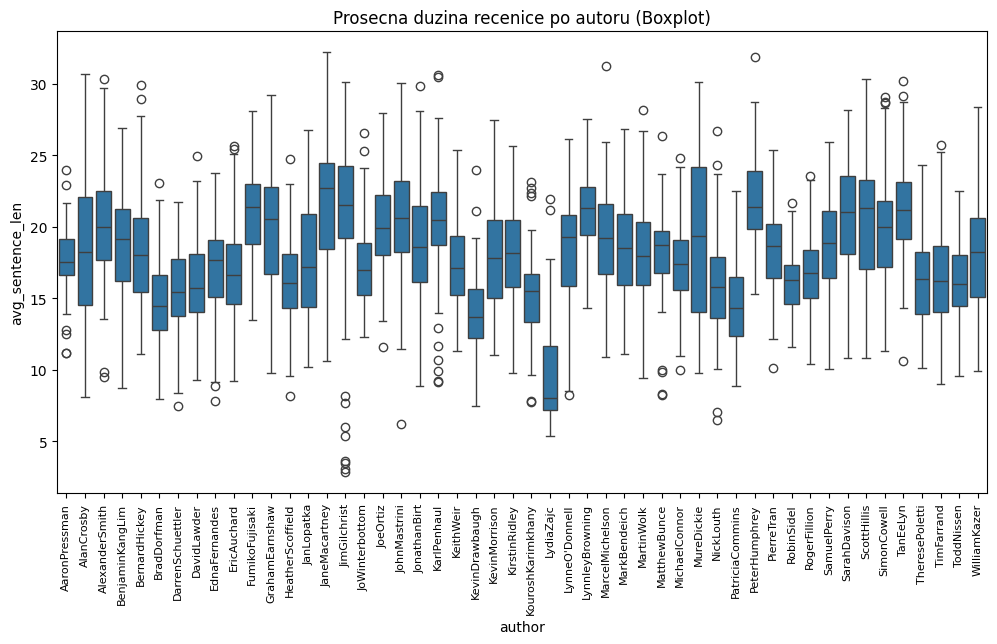

In [5]:


df['sentence_count'] = df['text'].apply(lambda x : len(re.split(r'[.!?]+', x)))
df['avg_sentence_len'] = df['word_count'] / df['sentence_count']

plt.figure(figsize=(12,6))
sns.boxplot(data = df, x = 'author', y = 'avg_sentence_len')
plt.xticks(rotation = 90,fontsize = 8)
plt.title("Prosecna duzina recenice po autoru (Boxplot)")

plt.show()

<span style="font-size: 17px;">**2.3 RACUNANJE BOGATSTVA RECNIKA**</span>

In [6]:
def lexical_diversity(text):
    words = text.lower().split()
    if (len(words)) == 0: return 0
    return len(set(words))/len(words)
df['lex_div'] = df['text'].apply(lexical_diversity)

#prikaz top10 autora po bogatstvu recnika
top_diverse = df.groupby('author')['lex_div'].mean().sort_values(ascending=False)
print("Autori sa najbogatijim rečnikom:\n", top_diverse.head(5))


Autori sa najbogatijim rečnikom:
 author
LydiaZajc       0.683498
JimGilchrist    0.627906
MarkBendeich    0.598177
KarlPenhaul     0.598149
AlanCrosby      0.592579
Name: lex_div, dtype: float64


<span style="font-size: 20px;">**3.PREPROCESIRANJE**</span>

In [7]:
lemmatizer = WordNetLemmatizer()

custom_stops = set(ENGLISH_STOP_WORDS).union({
    'said', 'million', 'billion', 'year', 'new', 'percent', 
    'company', 'market', 'analysts', 'shares', 'inc', 'corp'
})

def preprocess_and_lemmatize(text):

    text = text.lower()

    # izbacujemo sve sto nisu slova preko regexa 
    text = re.sub(r'[^a-z\s]', ' ', text)

    #izbacujemo reci koje smo dodatnom analizom videli da su ceste i da ne uticu na id autora, kao i one koje su manje od 2 slova
    words = [w for w in text.split() if w not in custom_stops and len(w) > 2]

    # stavljamo reci u isti oblik, npr. running, runs -> run
    lemmatized_words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(lemmatized_words)

df['clean_text'] = df['text'].apply(preprocess_and_lemmatize)

print("\n--- PROVERA PREPROCESIRANJA ---")
print(f'Originalni tekst:  prvih 60 karaktera :\n {df['text'].iloc[0][:60]}')
print("=" *60)
print(f'Ociscen i lematizovan tekst:  prvih 60 karaktera :\n {df['clean_text'].iloc[0][:60]}')


--- PROVERA PREPROCESIRANJA ---
Originalni tekst:  prvih 60 karaktera :
 An influential economic research group is preparing guidelin
Ociscen i lematizovan tekst:  prvih 60 karaktera :
 influential economic research group preparing guideline comp


<span style="font-size: 17px;">**3.1 TF-IDF MATRICA**</span>

In [8]:

#max_features = 5000, uzimamo top 5000 reci da izbegnemo preveliku matricu
#max_df = 0.8, izbacujemo reci koje se pojavljuju u preko 80 posto dokumetana
# min_df = 5, reci moraju da se pojave u bar 5 dokumenata da bi bile razmatrane
tfidf_vectorizer = TfidfVectorizer(max_features=5000,max_df=0.8, min_df=5)

X_tfidf = tfidf_vectorizer.fit_transform(df['clean_text'])

with open("../models/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf_vectorizer, f)


print(f"Preprocesiranje završeno.")
print(f"Finalna matrica ima {X_tfidf.shape[0]} redova (tekstovi) i {X_tfidf.shape[1]} kolona (reči/karakteristike).")

Preprocesiranje završeno.
Finalna matrica ima 5000 redova (tekstovi) i 5000 kolona (reči/karakteristike).


In [9]:
## skaliramo numericke kolene u dataFramu kako bi i one bile od 0 do 1 kao i TF-IDF matrica
scaler = MinMaxScaler()
feature_to_scale = ['lex_div', 'avg_sentence_len']
extra_features = scaler.fit_transform(df[feature_to_scale])

with open("../models/min_max_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)


X_final = hstack([X_tfidf,extra_features])
print("Finalna matrica je zavrsena")
print(X_final.shape)


Finalna matrica je zavrsena
(5000, 5002)


<span style="font-size: 20px;">**4.REDUKCIJA DIMENZIONALNOSTI I VIZUALIZACIJA**</span>

Originalni oblik(5000, 5002)
Redukovani oblik(5000, 2)
PC1 objašnjava: 2.95%
PC2 objašnjava: 1.63%
Ukupno na slici: 4.58%


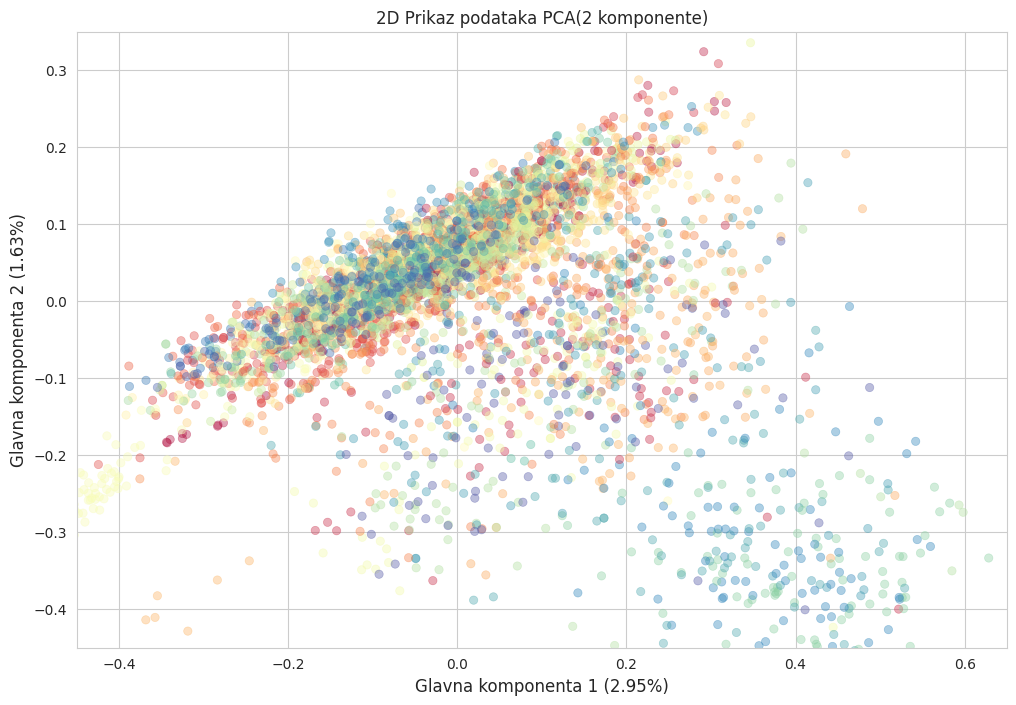

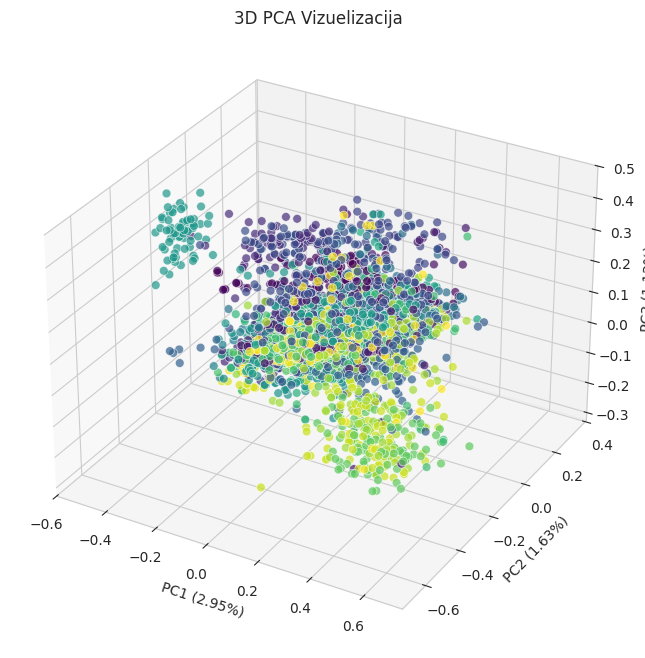

In [10]:
## 2d vizualizacija


pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_final.toarray())

print("Originalni oblik" + str(X_final.shape))
print("Redukovani oblik" + str(X_pca_2d.shape))

objasnjenja_varijansa  = pca_2d.explained_variance_ratio_ * 100
print(f"PC1 objašnjava: {objasnjenja_varijansa[0]:.2f}%")
print(f"PC2 objašnjava: {objasnjenja_varijansa[1]:.2f}%")
print(f"Ukupno na slici: {sum(objasnjenja_varijansa):.2f}%")

plt.figure(figsize=(12,8))
sns.set_style("whitegrid")


scatter = sns.scatterplot(
    x = X_pca_2d[:,0],
    y = X_pca_2d[:,1],
    alpha = 0.4,
    palette = 'Spectral',
    hue = df['author'],
    edgecolor = None,
    legend = False
)

plt.xlim(-0.45, 0.65) # Zumiramo x-osu
plt.ylim(-0.45, 0.35) # Zumiramo y-osu (ignorišemo tačke ispod -0.5)

plt.title("2D Prikaz podataka PCA(2 komponente)")
plt.xlabel(f"Glavna komponenta 1 ({objasnjenja_varijansa[0]:.2f}%)", fontsize=12)
plt.ylabel(f"Glavna komponenta 2 ({objasnjenja_varijansa[1]:.2f}%)", fontsize=12)
plt.show()

with open("../models/pca_2d.pkl", "wb") as f:
    pickle.dump(pca_2d, f)


## 3D PCA

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_final.toarray())



fig = plt.figure(figsize = (10,8),dpi = 100)
ax = fig.add_subplot(111,projection= '3d')

scatter = ax.scatter(X_pca_3d[:, 0], 
                     X_pca_3d[:, 1], 
                     X_pca_3d[:, 2], 
                     c=df['author'].astype('category').cat.codes, 
                     cmap='viridis', 
                     s=40, 
                     alpha=0.7,
                     edgecolors='w', # Dodajemo belu ivicu da se tačke ne stapaju
                     linewidth=0.5)

ax.set_title("3D PCA Vizuelizacija")
ax.set_xlabel(f"PC1 ({pca_3d.explained_variance_ratio_[0]*100:.2f}%)")
ax.set_ylabel(f"PC2 ({pca_3d.explained_variance_ratio_[1]*100:.2f}%)")
ax.set_zlabel(f"PC3 ({pca_3d.explained_variance_ratio_[2]*100:.2f}%)")

plt.show()


with open("../models/pca_3d.pkl", "wb") as f:
    pickle.dump(pca_3d, f)


<span style="font-size: 20px;">**5.KLASTEROVANJE - TRENIRANJE MODELA**</span>

In [11]:
## Treniranje modela KMeans sa celim skupom atributa

print("="*60)
print("--- POKRECEM TRENIRANJE KMEANS MODELA ---")
print("="*60)
X_dense = X_final.toarray()

kmeans = KMeans(n_clusters = 50, random_state= 42, n_init = 10)
labels_kmeans = kmeans.fit_predict(X_dense)

sse_kmeans_full = kmeans.inertia_
sil_kmeans_full = silhouette_score(X_dense,labels_kmeans)
hom_kmeans_full =  homogeneity_score(df['author'], labels_kmeans)
com_kmeans_full = completeness_score(df['author'], labels_kmeans)


with open("../models/kmeans_full_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)


print("---REZULTATI KMEANS----")
print("="*60)
print(f"Silhouette Score: {sil_kmeans_full:.3f}")
print(f"Homogenost:      {hom_kmeans_full:.3f}")
print(f"Kompletnost:     {com_kmeans_full:.3f}")
print(f"SSE (Inertia):    {sse_kmeans_full:,.0f}".replace(",", "."))

print("="*60)
print("--- POKRECEM TRENIRANJE KMEANS PCA MODEL--- ")
print("="*60)
pca_95 = PCA(n_components = 0.95, random_state =42)
X_pca_95 = pca_95.fit_transform(X_dense)
kmeans_pca = KMeans(n_clusters = 50, random_state= 42, n_init = 10)
labels_kmeans_pca = kmeans.fit_predict(X_pca_95)


sse_kmeans_pca = kmeans.inertia_
sil_kmeans_pca = silhouette_score(X_pca_95,labels_kmeans_pca)
hom_kmeans_pca =  homogeneity_score(df['author'], labels_kmeans_pca)
com_kmeans_pca = completeness_score(df['author'], labels_kmeans_pca)


## cuvamo model u ../models
with open("../models/kmeans_pca.pkl", "wb") as f:
    pickle.dump(kmeans_pca, f)


print("---REZULTATI  KMEANS SA PCA ----")
print("="*60)
print(f"Silhouette Score: {sil_kmeans_pca:.3f}")
print(f"Homogenost:      {hom_kmeans_pca:.3f}")
print(f"Kompletnost:     {com_kmeans_pca:.3f}")
print(f"SSE (Inertia):    {sse_kmeans_pca:,.0f}".replace(",", "."))



--- POKRECEM TRENIRANJE KMEANS MODELA ---
---REZULTATI KMEANS----
Silhouette Score: 0.068
Homogenost:      0.542
Kompletnost:     0.584
SSE (Inertia):    3.973
--- POKRECEM TRENIRANJE KMEANS PCA MODEL--- 
---REZULTATI  KMEANS SA PCA ----
Silhouette Score: 0.075
Homogenost:      0.526
Kompletnost:     0.584
SSE (Inertia):    3.722


In [12]:
##BiSecting KMeans
print("="*60)
print("--- POKRECEM TRENIRANJE BISECTION KMEANS MODELA ---")
print("="*60)
bkm = BisectingKMeans(n_clusters=50,n_init = 10,random_state=42)
labels_bkm_full = bkm.fit_predict(X_dense)

sse_bkm_full = bkm.inertia_
sil_bkm_full = silhouette_score(X_dense,labels_bkm_full)
hom_bkm_full = homogeneity_score(df['author'],labels_bkm_full)
com_bkm_full = completeness_score(df['author'],labels_bkm_full)

print("--- REZULTATI BISECTING KMEANS ---")
print("="*60)
print(f"Silhouette Score: {sil_bkm_full:.3f}")
print(f"Homogenost:      {hom_bkm_full:.3f}")
print(f"Kompletnost:     {com_bkm_full:.3f}")
print(f"SSE (Inertia):    {sse_bkm_full:,.0f}".replace(",", "."))

## cuvamo model 
with open("../models/bkm_full_model.pkl", "wb") as f:
    pickle.dump(bkm, f)


#BiSecting KMeans sa PCA
print("="*60)
print("--- POKRECEM TRENIRANJE BISECTION KMEANS PCA MODELA ---")
print("="*60)
bkm_pca = BisectingKMeans(n_clusters=50,n_init = 10,random_state=42)
labels_bkm_pca = bkm_pca.fit_predict(X_pca_95)
sse_bkm_pca = bkm.inertia_
sil_bkm_pca = silhouette_score(X_pca_95,labels_bkm_pca)
hom_bkm_pca = homogeneity_score(df['author'],labels_bkm_pca)
com_bkm_pca = completeness_score(df['author'],labels_bkm_pca)

print("--- REZULTATI BISECTING KMEANS SA PCA ---")
print("="*60)
print(f"Silhouette Score: {sil_bkm_pca:.3f}")
print(f"Homogenost:      {hom_bkm_pca:.3f}")
print(f"Kompletnost:     {com_bkm_pca:.3f}")
print(f"SSE (Inertia):    {sse_bkm_pca:,.0f}".replace(",", "."))


with open("../models/bkm_pca_model.pkl", "wb") as f:
    pickle.dump(bkm_pca, f)



--- POKRECEM TRENIRANJE BISECTION KMEANS MODELA ---
--- REZULTATI BISECTING KMEANS ---
Silhouette Score: 0.032
Homogenost:      0.509
Kompletnost:     0.535
SSE (Inertia):    4.193
--- POKRECEM TRENIRANJE BISECTION KMEANS PCA MODELA ---
--- REZULTATI BISECTING KMEANS SA PCA ---
Silhouette Score: 0.047
Homogenost:      0.496
Kompletnost:     0.537
SSE (Inertia):    4.193


In [13]:
print("--- POKRECEM TRENIRANJE AGGLOMERATIVE KLASTEROVANJA NA CELOM SKUPU ---")


# Definišemo linkage metode koje daju smislene rezultate
linkages = ['ward', 'complete', 'average','single']

print(f"\n{'Linkage':<12} | {'Siluete':<10} | {'Homogenost':<10} | {'Kompletnost':<10}")
print("-" * 75)

# Varijable za čuvanje (ovde će ostati poslednja iz petlje, ili specifično Ward)
sil_agg_pca = 0
hom_agg_pca = 0
com_agg_pca = 0

for link in linkages:

    agg = AgglomerativeClustering(n_clusters=50, linkage=link)
    labels = agg.fit_predict(X_dense)

    # Evaluacija
    sil = silhouette_score(X_dense, labels)
    hom = homogeneity_score(df['author'], labels)
    com = completeness_score(df['author'], labels)

    # Čuvamo rezultate za Ward metodu jer nam ona treba za finalni grafik
    if link == 'ward':
        sil_agg_full = sil
        hom_agg_full = hom
        com_agg_full = com
    name = "agg_" + link

    path = "../models/" + name + ".pkl" 
    with open(path, "wb") as f:
        pickle.dump(agg, f)

    
    print(f"{link:<12} | {sil:<10.3f} | {hom:<10.3f} | {com:<10.3f}")

print("\n--- ZAVRSENO TRENIRANJE NA CELOM SKUPU ---")

--- POKRECEM TRENIRANJE AGGLOMERATIVE KLASTEROVANJA NA CELOM SKUPU ---

Linkage      | Siluete    | Homogenost | Kompletnost
---------------------------------------------------------------------------
ward         | 0.065      | 0.515      | 0.582     
complete     | 0.035      | 0.433      | 0.508     
average      | 0.037      | 0.451      | 0.631     
single       | -0.034     | 0.015      | 0.432     

--- ZAVRSENO TRENIRANJE NA CELOM SKUPU ---


--- POKRECEM TRENIRANJE AGGLOMERATIVE KLASTEROVANJA NA PCA 95% ---

Linkage      | Siluete    | Homogenost | Kompletnost
---------------------------------------------------------------------------

Generišem dendrogram za ward metodu na celom skupu...


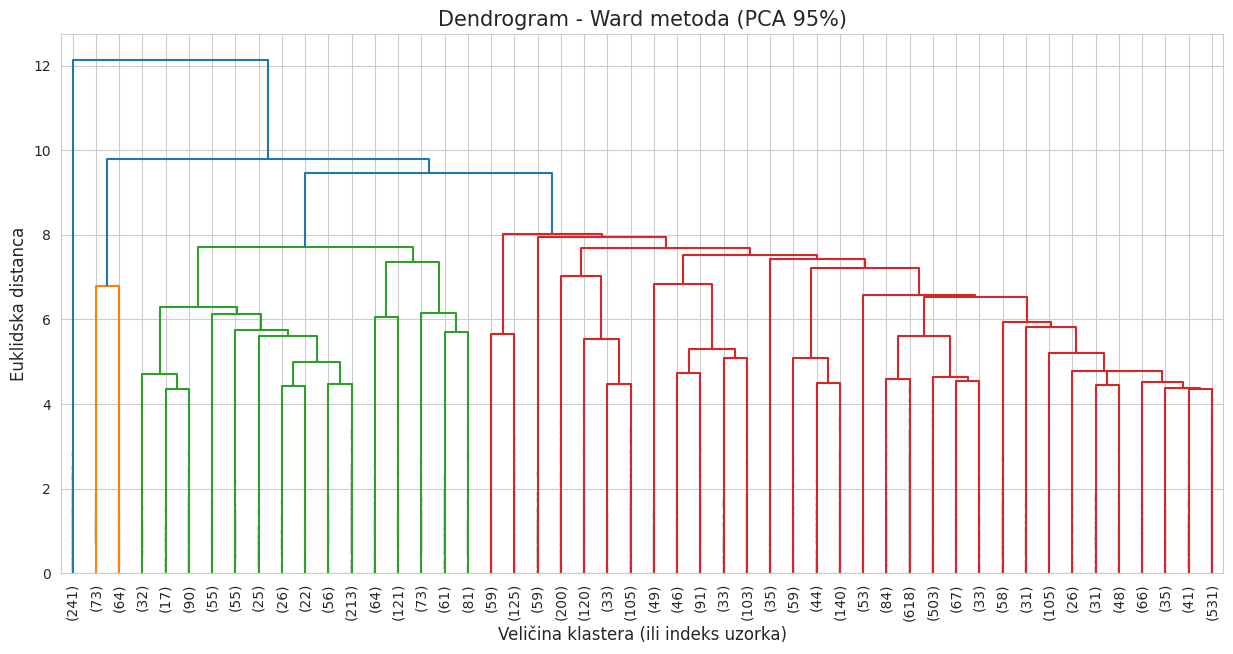

ward         | 0.069      | 0.514      | 0.583     
complete     | 0.034      | 0.422      | 0.489     
average      | 0.039      | 0.452      | 0.644     
single       | -0.031     | 0.015      | 0.432     

--- ZAVRSENO TRENIRANJE NA PCA  SKUPU ---


In [14]:
print("--- POKRECEM TRENIRANJE AGGLOMERATIVE KLASTEROVANJA NA PCA 95% ---")


linkages = ['ward', 'complete', 'average', 'single']

print(f"\n{'Linkage':<12} | {'Siluete':<10} | {'Homogenost':<10} | {'Kompletnost':<10}")
print("-" * 75)

# Varijable za čuvanje (ovde će ostati poslednja iz petlje, ili specifično Ward)
sil_agg_pca = 0
hom_agg_pca = 0
com_agg_pca = 0

for link in linkages:

    
    agg = AgglomerativeClustering(n_clusters=50, linkage=link)
    labels = agg.fit_predict(X_pca_95)
    

    # Evaluacija
    sil = silhouette_score(X_pca_95, labels)
    hom = homogeneity_score(df['author'], labels)
    com = completeness_score(df['author'], labels)

    name = "agg_pca_" + link

    path = "../models/" + name + ".pkl" 
    with open(path, "wb") as f:
        pickle.dump(agg, f)
        
    #trebace nam vrednosti za ward za grafik
    if link == 'ward':
        sil_agg_pca = sil
        hom_agg_pca = hom
        com_agg_pca = com

        
        print(f"\nGenerišem dendrogram za {link} metodu na celom skupu...")
        plt.figure(figsize=(15, 7))
        
        # linkage funkcija iz scipy-a je neophodna za dendrogram
        Z = sch.linkage(X_pca_95, method='ward')
        
        # truncate_mode='lastp' prikazuje samo poslednjih p čvorova
        sch.dendrogram(Z, truncate_mode='lastp', p=50, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
        
        plt.title(f"Dendrogram - Ward metoda (PCA 95%)", fontsize=15)
        plt.xlabel("Veličina klastera (ili indeks uzorka)", fontsize=12)
        plt.ylabel("Euklidska distanca", fontsize=12)
        plt.axhline(y=15, color='r', linestyle='--') # Opciona linija koja pokazuje gde bi se seklo za klastere
        plt.show()
        # -------------------------------------------------------------

    print(f"{link:<12} | {sil:<10.3f} | {hom:<10.3f} | {com:<10.3f}")

print("\n--- ZAVRSENO TRENIRANJE NA PCA  SKUPU ---")

In [15]:
print("="*60)
print("--- POKRECEM TRENIRANJE DBSCAN MODELA ---")
print("="*60)

dbscan = DBSCAN(eps = 0.6,min_samples= 5)
dbscan_labels = dbscan.fit_predict(X_final)
print("----- DBSCAN REZULTATI -----")
print("="*60)
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
sil_full_db = silhouette_score(X_final, dbscan_labels)
hom_full_db = homogeneity_score(df['author'], dbscan_labels)
com_full_db = completeness_score(df['author'], dbscan_labels)

print(f"Pronađeno klastera: {n_clusters}")
print(f"Broj tačaka koje su označene kao ŠUM: {n_noise} od ukupno {len(df)}")
print(f'Siluet score: {sil_full_db:.3f}')
print(f'Homogenost : {hom_full_db:.3f}')
print(f'Kompletnost: {com_full_db:.3f}')

with open("../models/db_scan.pkl", "wb") as f:
    pickle.dump(dbscan, f)

print("="*60)
print("--- POKRECEM TRENIRANJE DBSCAN MODELA NA PCA PODACIMA ----")
print("="*60)

dbscan_pca = DBSCAN(eps = 0.6,min_samples=5)
dbscan_labels_pca = dbscan.fit_predict(X_pca_95)
print("----- DBSCAN PCA REZULTATI -----")
print("="*60)
n_clusters_pca = len(set(dbscan_labels_pca)) - (1 if -1 in dbscan_labels_pca else 0)
n_noise_pca = list(dbscan_labels_pca).count(-1)
sil_pca_db = silhouette_score(X_pca_95, dbscan_labels_pca)
hom_pca_db = homogeneity_score(df['author'], dbscan_labels_pca)
com_pca_db = completeness_score(df['author'], dbscan_labels_pca)


print(f"Pronađeno klastera: {n_clusters_pca}")
print(f"Broj tačaka koje su označene kao ŠUM: {n_noise_pca} od ukupno {len(df)}")
print(f'Siluet score: {sil_pca_db:.3f}')
print(f'Homogenost : {hom_pca_db:.3f}')
print(f'Kompletnost: {com_pca_db:.3f}')

with open("../models/db_scan_pca.pkl", "wb") as f:
    pickle.dump(dbscan_pca ,f)



--- POKRECEM TRENIRANJE DBSCAN MODELA ---
----- DBSCAN REZULTATI -----
Pronađeno klastera: 16
Broj tačaka koje su označene kao ŠUM: 4881 od ukupno 5000
Siluet score: -0.032
Homogenost : 0.023
Kompletnost: 0.515
--- POKRECEM TRENIRANJE DBSCAN MODELA NA PCA PODACIMA ----
----- DBSCAN PCA REZULTATI -----
Pronađeno klastera: 48
Broj tačaka koje su označene kao ŠUM: 4624 od ukupno 5000
Siluet score: -0.044
Homogenost : 0.071
Kompletnost: 0.512


In [16]:
print("="*60)
print("--- POKRECEM TRENIRANJE BIRCH MODELA ---")
print("="*60)

birch = Birch(n_clusters=50,threshold=0.5,branching_factor=50)
birch_labels = birch.fit_predict(X_final)

sil_birch_full = silhouette_score(X_final,birch_labels)
hom_birch_full = homogeneity_score(df['author'], birch_labels)
com_birch_full = completeness_score(df['author'], birch_labels)
print("--- REZULTATI BIRCH ---")
print("="*60)
print(f'Siluet score: {sil_birch_full:.3f}')
print(f'Homogenost : {hom_birch_full:.3f}')
print(f'Kompletnost: {com_birch_full:.3f}')
print("="*60)

with open("../models/birch.pkl", "wb") as f:
    pickle.dump(birch,f)



print("--- POKRECEM TRENIRANJE BIRCH PCA MODELA ---")
print("="*60)
birch_pca = Birch(n_clusters=50,threshold=0.5,branching_factor=50)
birch_labels_pca = birch_pca.fit_predict(X_pca_95)
sil_birch_pca = silhouette_score(X_pca_95,birch_labels_pca)
hom_birch_pca = homogeneity_score(df['author'], birch_labels_pca)
com_birch_pca = completeness_score(df['author'], birch_labels_pca)
print("--- REZULTATI BIRCH PCA ---")
print("="*60)

print(f'Siluet score: {sil_birch_pca:.3f}')
print(f'Homogenost : {hom_birch_pca:.3f}')
print(f'Kompletnost: {com_birch_pca:.3f}')

with open("../models/birch_pca.pkl", "wb") as f:
    pickle.dump(birch_pca,f)




--- POKRECEM TRENIRANJE BIRCH MODELA ---
--- REZULTATI BIRCH ---
Siluet score: 0.054
Homogenost : 0.511
Kompletnost: 0.573
--- POKRECEM TRENIRANJE BIRCH PCA MODELA ---
--- REZULTATI BIRCH PCA ---
Siluet score: 0.051
Homogenost : 0.533
Kompletnost: 0.579


In [17]:
print("="*60)
print("---POKRECEM TRENIRANJE GMM MODELA---")
print("="*60)
gmm = GaussianMixture(n_components=50,covariance_type='diag',random_state=42)
gmm_labels_full = gmm.fit_predict(X_dense)

sil_gmm_full = silhouette_score(X_dense,gmm_labels_full)
hom_gmm_full = homogeneity_score(df['author'],gmm_labels_full)
com_gmm_full = completeness_score(df['author'],gmm_labels_full)

print("--- REZULTATI GMM ---")
print("="*60)
print(f'Siluet score: {sil_gmm_full:.3f}')
print(f'Homogenost : {hom_gmm_full:.3f}')
print(f'Kompletnost: {com_gmm_full:.3f}')
print("="*60)


with open("../models/gmm.pkl", "wb") as f:
    pickle.dump(gmm,f)


print("--- POKRECEM TRENIRANJE GMM PCA MODELA ---")

gmm_pca = GaussianMixture(n_components=50,covariance_type='diag',random_state=42)
gmm_labels_pca = gmm_pca.fit_predict(X_pca_95)

sil_gmm_pca = silhouette_score(X_pca_95,gmm_labels_pca)
hom_gmm_pca = homogeneity_score(df['author'],gmm_labels_pca)
com_gmm_pca = completeness_score(df['author'],gmm_labels_pca)
print("="*60)
print("--- REZULTATI GMM FULL ---")
print("="*60)
print(f'Siluet score: {sil_gmm_pca:.3f}')
print(f'Homogenost : {hom_gmm_pca:.3f}')
print(f'Kompletnost: {com_gmm_pca:.3f}')
print("="*60)

with open("../models/gmm_pca.pkl", "wb") as f:
    pickle.dump(gmm_pca,f)

---POKRECEM TRENIRANJE GMM MODELA---
--- REZULTATI GMM ---
Siluet score: 0.062
Homogenost : 0.530
Kompletnost: 0.573
--- POKRECEM TRENIRANJE GMM PCA MODELA ---
--- REZULTATI GMM FULL ---
Siluet score: 0.039
Homogenost : 0.388
Kompletnost: 0.439


<span style="font-size: 20px;">**6..ANALIZA I POREDJENJE REZULTATA**</span>

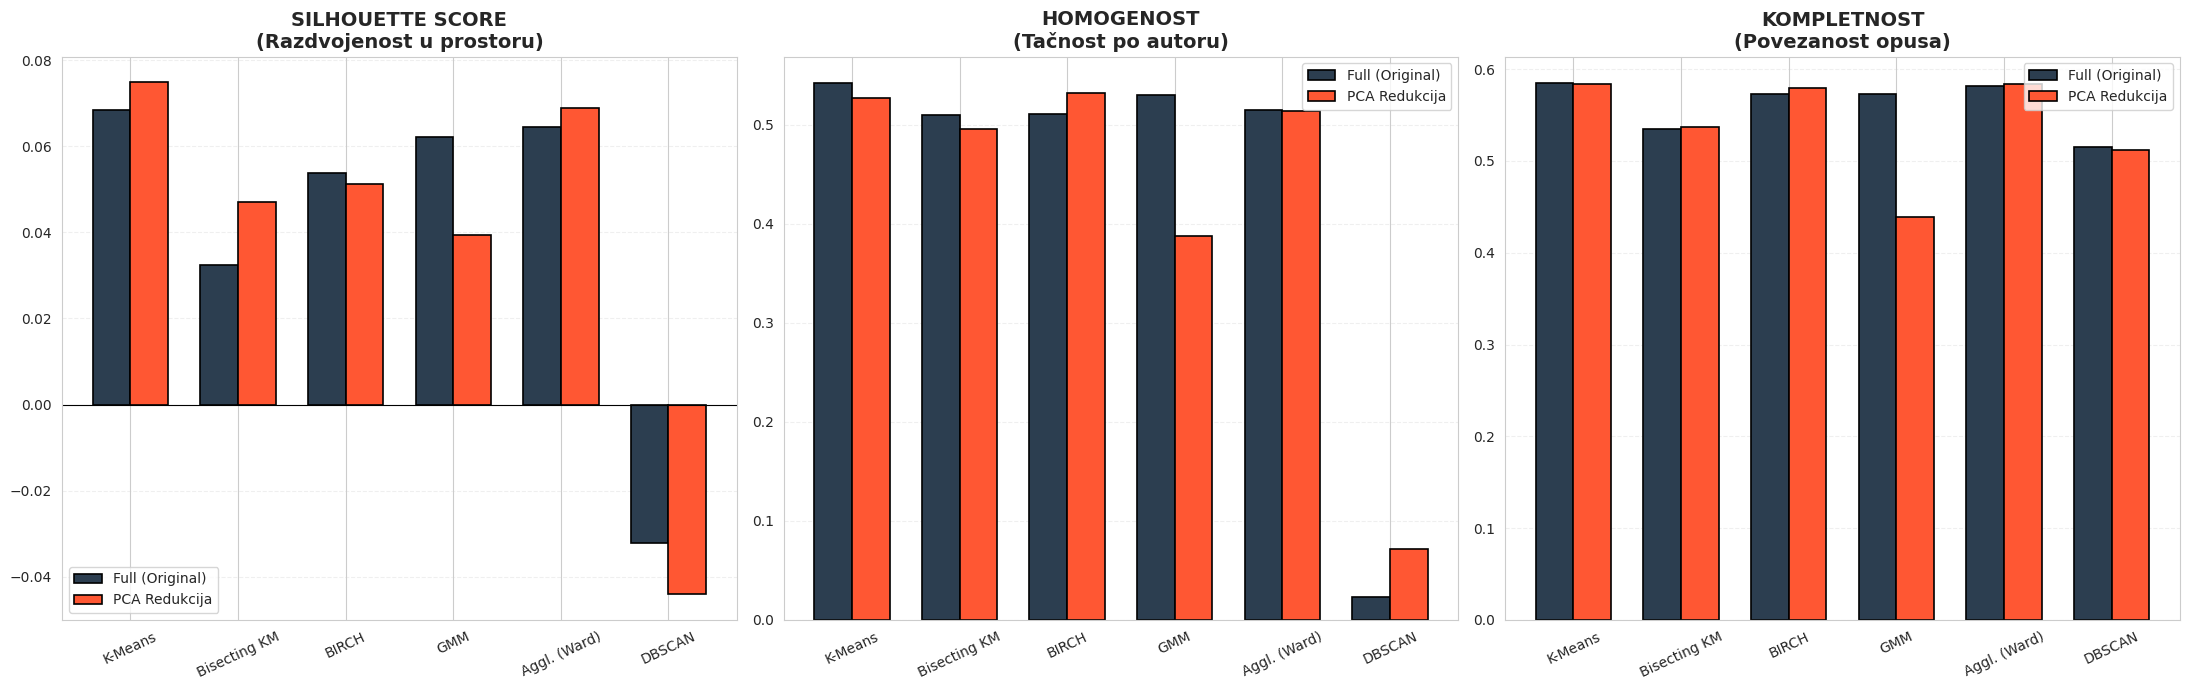

In [18]:

modeli = ['K-Means', 'Bisecting KM', 'BIRCH', 'GMM', 'Aggl. (Ward)','DBSCAN']


# 1. Silhouette rezultati
sil_full = [sil_kmeans_full, sil_bkm_full, sil_birch_full, sil_gmm_full, sil_agg_full,sil_full_db] 
sil_pca  = [sil_kmeans_pca, sil_bkm_pca, sil_birch_pca, sil_gmm_pca, sil_agg_pca,sil_pca_db] 

# 2. Homogenost rezultati
hom_full = [hom_kmeans_full, hom_bkm_full, hom_birch_full, hom_gmm_full, hom_agg_full,hom_full_db]
hom_pca  = [hom_kmeans_pca, hom_bkm_pca, hom_birch_pca, hom_gmm_pca, hom_agg_pca,hom_pca_db]

# 3. Kompletnost rezultati
com_full = [com_kmeans_full, com_bkm_full, com_birch_full, com_gmm_full, com_agg_full,com_full_db]
com_pca  = [com_kmeans_pca, com_bkm_pca, com_birch_pca, com_gmm_pca, com_agg_pca,com_pca_db]

x = np.arange(len(modeli))
width = 0.35

boja_full = '#2C3E50'
boja_pca  = '#FF5733' 

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 7))

# --- 1. SILHOUETTE SCORE ---
ax1.bar(x - width/2, sil_full, width, label='Full (Original)', color=boja_full, edgecolor='black', linewidth=1.2)
ax1.bar(x + width/2, sil_pca, width, label='PCA Redukcija', color=boja_pca, edgecolor='black', linewidth=1.2)
ax1.set_title('SILHOUETTE SCORE\n(Razdvojenost u prostoru)', fontweight='bold', fontsize=14)
ax1.set_xticks(x)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_xticklabels(modeli, rotation=25)
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax1.legend()

# --- 2. HOMOGENOST ---
ax2.bar(x - width/2, hom_full, width, label='Full (Original)', color=boja_full, edgecolor='black', linewidth=1.2)
ax2.bar(x + width/2, hom_pca, width, label='PCA Redukcija', color=boja_pca, edgecolor='black', linewidth=1.2)
ax2.set_title('HOMOGENOST\n(Tačnost po autoru)', fontweight='bold', fontsize=14)
ax2.set_xticks(x)
ax2.set_xticklabels(modeli, rotation=25)
ax2.grid(axis='y', linestyle='--', alpha=0.3)
ax2.legend()

# --- 3. KOMPLETNOST ---
ax3.bar(x - width/2, com_full, width, label='Full (Original)', color=boja_full, edgecolor='black', linewidth=1.2)
ax3.bar(x + width/2, com_pca, width, label='PCA Redukcija', color=boja_pca, edgecolor='black', linewidth=1.2)
ax3.set_title('KOMPLETNOST\n(Povezanost opusa)', fontweight='bold', fontsize=14)
ax3.set_xticks(x)
ax3.set_xticklabels(modeli, rotation=25)
ax3.grid(axis='y', linestyle='--', alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.show()